In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/3) Sentiment dataset.csv")

Mounted at /content/drive


In [ ]:
df.shape

(732, 15)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Text,0
Sentiment,0
Timestamp,0
User,0
Platform,0
Hashtags,0
Retweets,0
Likes,0


In [ ]:
duplicate_rows = df[df.duplicated()]
print(f"\n No of duplicate rows: {duplicate_rows.shape[0]}")


 No of duplicate rows: 0


In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
from textblob import TextBlob
from wordcloud import WordCloud

In [ ]:
!pip install nltk textblob wordcloud

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')


In [ ]:
# Text preprocessing
import re
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
  text = text.lower()
  text = re.sub(r'[^a-z\s]', '', text)
  tokens = nltk.word_tokenize(text)
  tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
  return " ".join(tokens)

df['clean_text'] = df['Text'].astype(str).apply(preprocess_text)
df[['Text', 'clean_text']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Text,clean_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


In [ ]:
#sentiment
def get_sentiment(text):
  polarity = TextBlob(text).sentiment.polarity
  if polarity > 0:
    return "Positive"
  elif polarity < 0:
    return "Negative"
  else:
    return "Neutral"
df['sentiment'] = df['clean_text'].apply(get_sentiment)
df[['clean_text','sentiment']].head()

,clean_text,sentiment
0,enjoying beautiful day park,Positive
1,traffic terrible morning,Negative
2,finished amazing workout,Positive
3,excited upcoming weekend getaway,Positive
4,trying new recipe dinner tonight,Positive


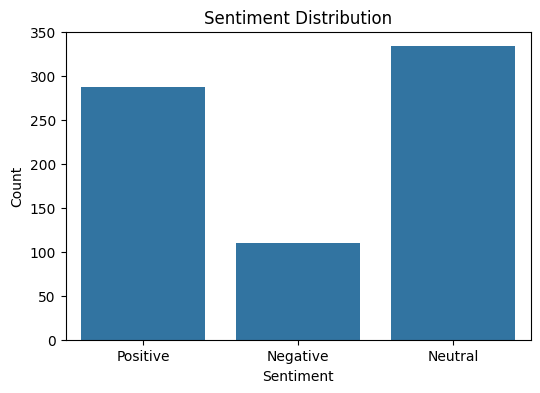

In [ ]:
import seaborn as sn
plt.figure(figsize=(6,4))
sn.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel("Count")
plt.show()

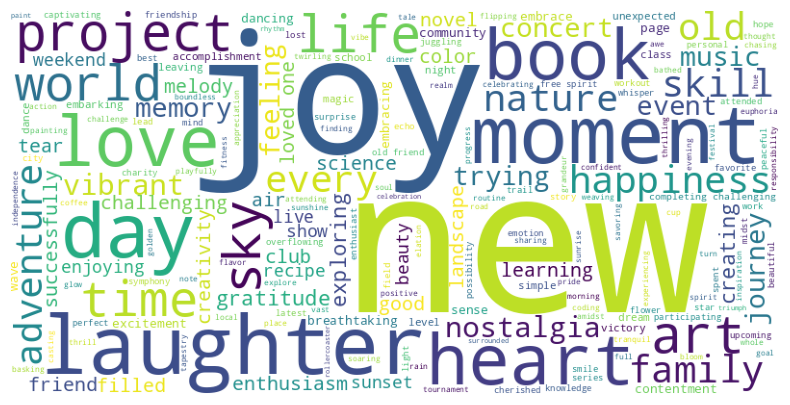

In [ ]:
# Wordcloud Positive
positive_text = " ".join(df[df['sentiment']=="Positive"]['clean_text'])
wc_pos = WordCloud(width = 800, height = 400, background_color = 'white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos)
plt.axis("off")
#plt.title('Sentiment Positive')
plt.show()

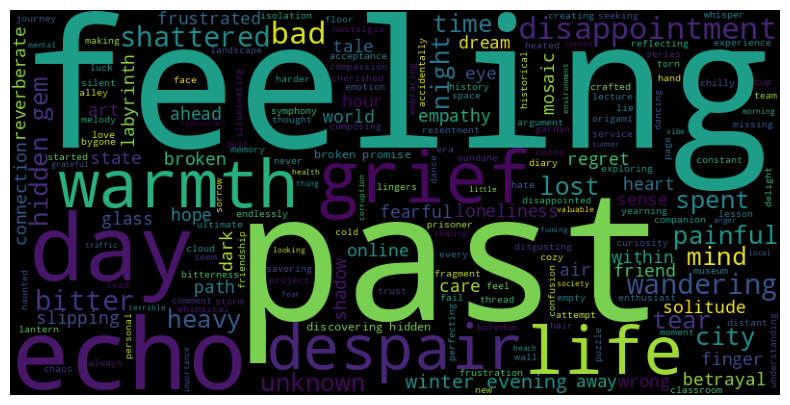

In [ ]:
# Wordcloud Negative
negative_text = " ".join(df[df['sentiment']=="Negative"]['clean_text'])
wc_neg = WordCloud(width = 800, height = 400, background_color = 'black').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg)
plt.axis("off")
plt.show()

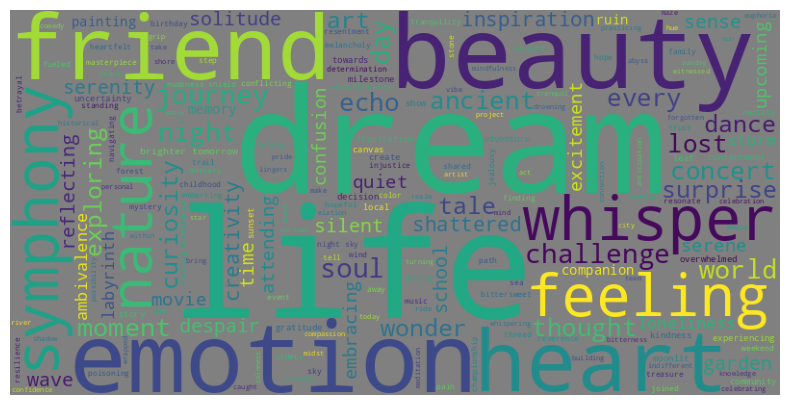

In [ ]:
# Neutral
neutral_text = " ".join(df[df['sentiment']=="Neutral"]['clean_text'])
wc_nu = WordCloud(width = 800, height = 400, background_color = 'grey').generate(neutral_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_nu)
plt.axis("off")
plt.show()

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Neutral,334
Positive,288
Negative,110
